**RQ4: How frequently are specific political leaders (Merz, Trump, Biden, and Scholz) associated with positive and negative tone in news coverage across two legislative periods?**

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")


In [42]:
df = pd.read_csv("Data/tagesschau_zdf_pbs_foxnews_bild_gkg_partitioned_full_2021.csv")


df["Datetime"] = pd.to_datetime(df["DATE"].astype(str).str[:14], format="%Y%m%d%H%M%S")
df["Date"] = df["Datetime"].dt.date

df["Tone"] = df["V2Tone"].str.split(",").str[0].astype(float)

In [43]:
leaders = ["Biden", "Trump", "Scholz", "Merz"]

def extract_leader(persons_str):
    if not isinstance(persons_str, str):
        return None
    for leader in leaders:
        if leader in persons_str:
            return leader
    return None

df["Leader"] = df["V2Persons"].apply(extract_leader)
leaders_df = df[df["Leader"].notna()].copy()

# Date as timestamp for period mapping
leaders_df["Date"] = pd.to_datetime(leaders_df["Date"])


In [44]:
tone_bins = [-100, -0.01, 0.01, 100]
tone_labels = ["Negative", "Neutral/none", "Positive"]

leaders_df["ToneCategory"] = pd.cut(
    leaders_df["Tone"],
    bins=tone_bins,
    labels=tone_labels,
    right=True
)


In [45]:

leaders_country = {
    "Scholz": "DE",
    "Merz":  "DE",
    "Biden": "US",
    "Trump": "US"
}
leaders_df["Country"] = leaders_df["Leader"].map(leaders_country)


leaders_df["Date"] = pd.to_datetime(leaders_df["Date"])

def map_german_period(ts):
    ts = pd.Timestamp(ts)
    # Period 1 DE: 8.12.2021 - 6.5.2025
    if pd.Timestamp("2021-12-08") <= ts < pd.Timestamp("2025-05-06"):
        return "Period_DE_1"
    # Period 2 DE: 6.5.2025 - 16.3.2026
    elif pd.Timestamp("2025-05-06") <= ts <= pd.Timestamp("2026-03-16"):
        return "Period_DE_2"
    else:
        return "Outside_DE"

def map_us_period(ts):
    ts = pd.Timestamp(ts)
    # Period 1 US: 8.12.2021 - 20.1.2025
    if pd.Timestamp("2021-12-08") <= ts < pd.Timestamp("2025-01-20"):
        return "Period_US_1"
    # Period 2 US: 20.1.2025 - 16.3.2026
    elif pd.Timestamp("2025-01-20") <= ts <= pd.Timestamp("2026-03-16"):
        return "Period_US_2"
    else:
        return "Outside_US"

leaders_df["PeriodLegis"] = None

mask_de = leaders_df["Country"] == "DE"
leaders_df.loc[mask_de, "PeriodLegis"] = leaders_df.loc[mask_de, "Date"].apply(map_german_period)

mask_us = leaders_df["Country"] == "US"
leaders_df.loc[mask_us, "PeriodLegis"] = leaders_df.loc[mask_us, "Date"].apply(map_us_period)


valid_periods = ["Period_DE_1", "Period_DE_2", "Period_US_1", "Period_US_2"]
leaders_df = leaders_df[leaders_df["PeriodLegis"].isin(valid_periods)].copy()


In [46]:
period_label_map = {
    "Period_DE_1": "08.12.2021 – 06.05.2025",
    "Period_DE_2": "06.05.2025 – 16.03.2026",
    "Period_US_1": "08.12.2021 – 20.01.2025",
    "Period_US_2": "20.01.2025 – 16.03.2026"
}

In [47]:
counts = (
    leaders_df
    .groupby(["Leader", "PeriodLegis", "ToneCategory"], as_index=False, observed=True)
    .size()
    .rename(columns={"size": "NumArticles"})
)


In [48]:
counts_pct = counts.copy()
counts_pct["TotalLeaderPeriod"] = counts_pct.groupby(
    ["Leader", "PeriodLegis"]
)["NumArticles"].transform("sum")

counts_pct["Pct"] = 100 * counts_pct["NumArticles"] / counts_pct["TotalLeaderPeriod"]


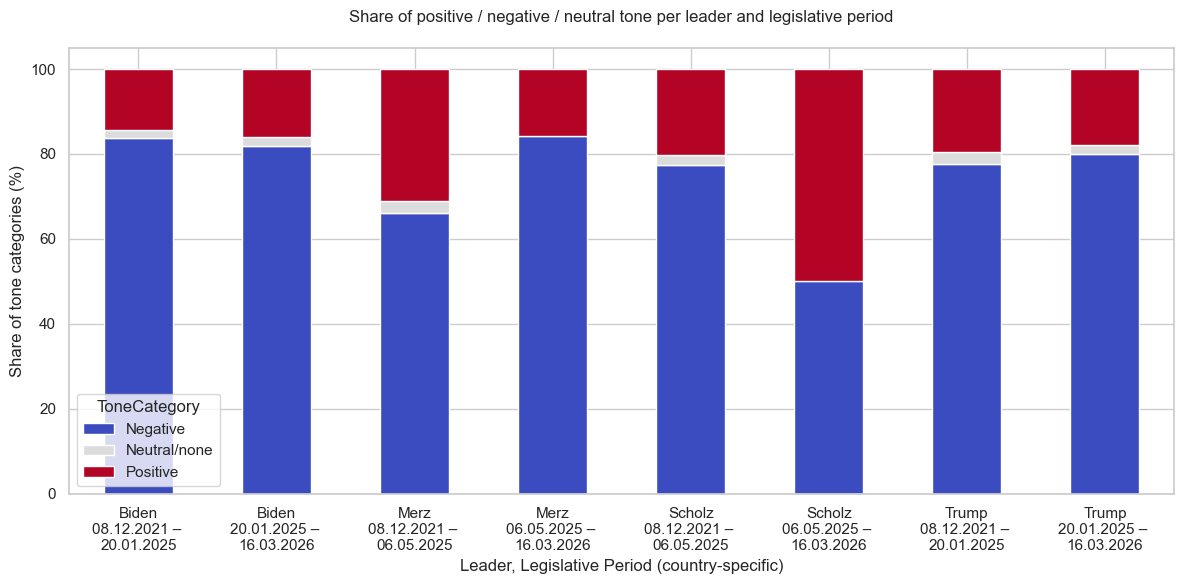

In [49]:
period_label_map = {
    "Period_DE_1": "08.12.2021 – \n06.05.2025",
    "Period_DE_2": "06.05.2025 – \n16.03.2026",
    "Period_US_1": "08.12.2021 – \n20.01.2025",
    "Period_US_2": "20.01.2025 – \n16.03.2026"
}

pivot_pct = counts_pct.pivot_table(
    index=["Leader", "PeriodLegis"],
    columns="ToneCategory",
    values="Pct",
    fill_value=0,
    observed=False,
)


new_labels = [
    f"{leader}\n{period_label_map.get(period, period)}"
    for leader, period in pivot_pct.index
]

ax = pivot_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="coolwarm",
)

plt.title(
    "Share of positive / negative / neutral tone per leader and legislative period\n"
)
plt.xlabel("Leader, Legislative Period (country-specific)")
plt.ylabel("Share of tone categories (%)")

ax.set_xticklabels(new_labels, rotation=0, ha="center")

plt.tight_layout()
plt.show()


In [50]:
period_label_map = {
    "Period_DE_1": "08.12.2021 – 06.05.2025",
    "Period_DE_2": "06.05.2025 – 16.03.2026",
    "Period_US_1": "08.12.2021 – 20.01.2025",
    "Period_US_2": "20.01.2025 – 16.03.2026"
}

In [51]:
import matplotlib.pyplot as plt

us = counts[counts["Leader"].isin(["Biden", "Trump"])]
us_totals = (
    us.groupby("ToneCategory", as_index=False, observed=True)["NumArticles"]
      .sum()
)
us_totals["Pct"] = 100 * us_totals["NumArticles"] / us_totals["NumArticles"].sum()

de = counts[counts["Leader"].isin(["Scholz", "Merz"])]
de_totals = (
    de.groupby("ToneCategory", as_index=False, observed=True)["NumArticles"]
      .sum()
)
de_totals["Pct"] = 100 * de_totals["NumArticles"] / de_totals["NumArticles"].sum()

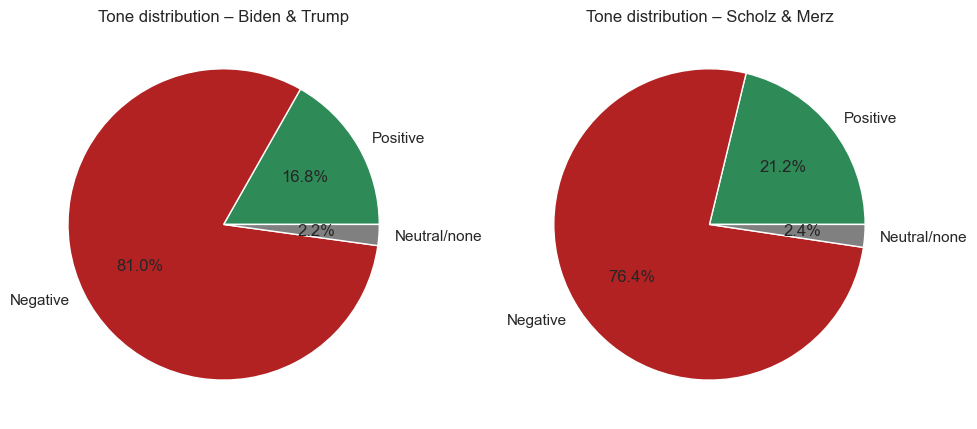

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

tone_focus = ["Positive", "Negative", "Neutral/none"]
colors = {
    "Positive": "seagreen",
    "Negative": "firebrick",
    "Neutral/none": "gray",
}

# US-Pie (Biden + Trump)
us_plot = us_totals.set_index("ToneCategory").reindex(tone_focus).dropna(subset=["Pct"])
axes[0].pie(
    us_plot["NumArticles"],
    labels=us_plot.index,
    autopct="%1.1f%%",
    colors=[colors[t] for t in us_plot.index],
)
axes[0].set_title("Tone distribution – Biden & Trump")

# DE-Pie (Scholz + Merz)
de_plot = de_totals.set_index("ToneCategory").reindex(tone_focus).dropna(subset=["Pct"])
axes[1].pie(
    de_plot["NumArticles"],
    labels=de_plot.index,
    autopct="%1.1f%%",
    colors=[colors[t] for t in de_plot.index],
)
axes[1].set_title("Tone distribution – Scholz & Merz")

plt.tight_layout()
plt.show()


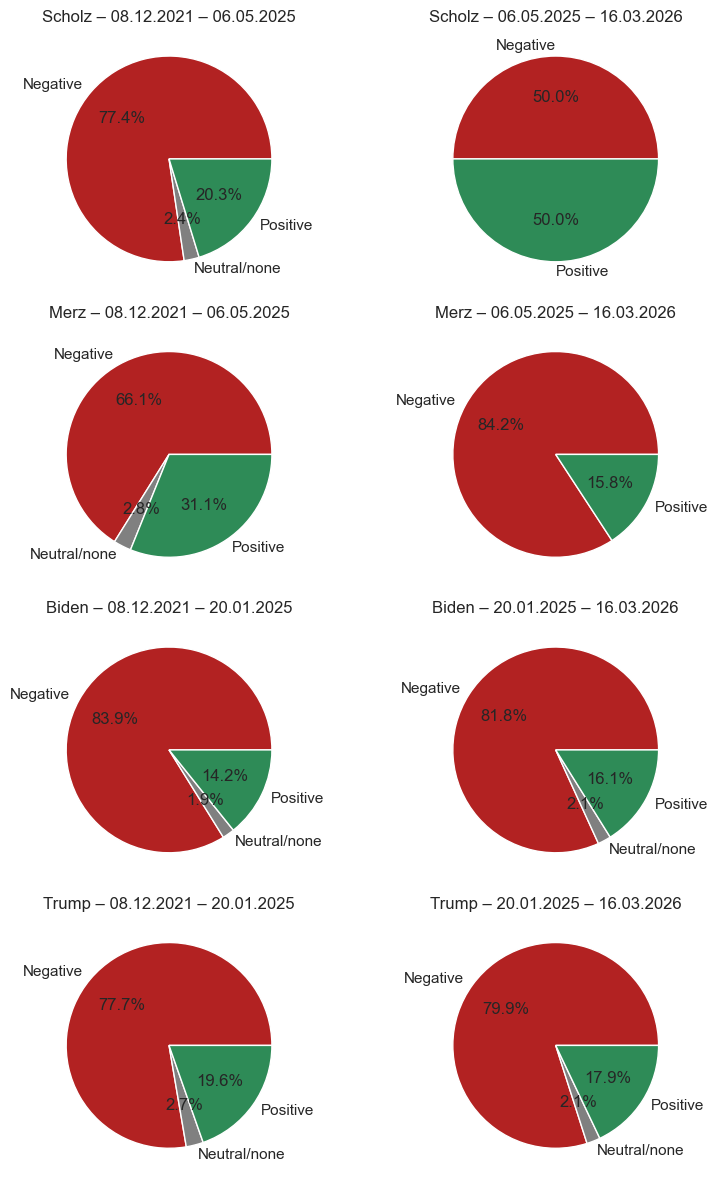

In [53]:
tone_focus = ["Positive", "Negative", "Neutral/none"]

leaders_order = ["Scholz", "Merz", "Biden", "Trump"]
periods_order = ["Period_DE_1", "Period_DE_2", "Period_US_1", "Period_US_2"]

leader_period_map = {
    "Scholz": ["Period_DE_1", "Period_DE_2"],
    "Merz":   ["Period_DE_1", "Period_DE_2"],
    "Biden":  ["Period_US_1", "Period_US_2"],
    "Trump":  ["Period_US_1", "Period_US_2"],
}

fig, axes = plt.subplots(
    len(leaders_order), 2,
    figsize=(8, 3 * len(leaders_order))
)

colors_map = {
    "Positive": "seagreen",
    "Negative": "firebrick",
    "Neutral/none": "gray"
}

for i, leader in enumerate(leaders_order):
    per_list = leader_period_map[leader]
    for j in range(2):
        ax = axes[i, j]
        if j >= len(per_list):
            ax.set_visible(False)
            continue

        per = per_list[j]

        sub = counts[
            (counts["Leader"] == leader)
            & (counts["PeriodLegis"] == per)
            & (counts["ToneCategory"].isin(tone_focus))
        ]

        if sub.empty or sub["NumArticles"].fillna(0).sum() == 0:
            ax.set_visible(False)
            continue

        ax.pie(
            sub["NumArticles"],
            labels=sub["ToneCategory"],
            autopct="%1.1f%%",
            colors=[colors_map[t] for t in sub["ToneCategory"]]
        )
        ax.set_title(f"{leader} – {period_label_map.get(per, per)}")

plt.tight_layout()
plt.show()


**Interactive ones:**

In [54]:
import plotly.graph_objects as go

tone_focus = ["Positive", "Negative", "Neutral/none"]

leaders_order = ["Scholz", "Merz", "Biden", "Trump"]
periods_order = ["Period_DE_1", "Period_DE_2", "Period_US_1", "Period_US_2"]

leader_period_map = {
    "Scholz": ["Period_DE_1", "Period_DE_2"],
    "Merz":   ["Period_DE_1", "Period_DE_2"],
    "Biden":  ["Period_US_1", "Period_US_2"],
    "Trump":  ["Period_US_1", "Period_US_2"],
}

colors_map = {
    "Positive": "seagreen",
    "Negative": "firebrick",
    "Neutral/none": "gray"
}

fig = go.Figure()
n_rows = len(leaders_order)
n_cols = 2

v_gap = 0.09
usable_height = 1 - v_gap * (n_rows - 1)

annotations = []

for i, leader in enumerate(leaders_order):
    per_list = leader_period_map[leader]
    for j in range(n_cols):
        if j >= len(per_list):
            continue

        per = per_list[j]

        sub = counts[
            (counts["Leader"] == leader)
            & (counts["PeriodLegis"] == per)
            & (counts["ToneCategory"].isin(tone_focus))
        ]

        if sub.empty or sub["NumArticles"].fillna(0).sum() == 0:
            continue

        x0 = j / n_cols
        x1 = (j + 1) / n_cols
        y0 = 1 - usable_height * (i + 1) / n_rows - v_gap * i
        y1 = 1 - usable_height * i / n_rows   - v_gap * i

        fig.add_trace(
            go.Pie(
                labels=sub["ToneCategory"],
                values=sub["NumArticles"],
                name=f"{leader} – {per}",
                marker=dict(colors=[colors_map[t] for t in sub["ToneCategory"]]),
                textinfo="percent+label",
                hovertemplate=(
                    f"Leader: {leader}<br>"
                    f"Period: {period_label_map.get(per, per)}<br>"
                    "Tone: %{label}<br>"
                    "Articles: %{value}<extra></extra>"
                ),
                domain=dict(x=[x0, x1], y=[y0, y1]),
                legendgroup="Tone",
                showlegend=(i == 0 and j == 0)
            )
        )

        annotations.append(
            dict(
                x=(x0 + x1) / 2,
                y=y1 + 0.03,
                xref="paper",
                yref="paper",
                text=f"{leader} – {period_label_map.get(per, per)}",
                showarrow=False,
                xanchor="center",
                yanchor="bottom",
                font=dict(size=12)
            )
        )

fig.update_layout(
    height=250 * n_rows,
    width=800,
    title_text="Tone distribution by leader and legislative period (interactive)",
    legend_title_text="Tone category",
    annotations=annotations
)

fig.show()
fig.write_html("rq4_tone_per_leg_period_cake.html", include_plotlyjs="cdn")


In [55]:
import plotly.express as px

df_long = counts_pct.copy()
df_long["PeriodLabel"] = df_long["PeriodLegis"].map(period_label_map)

fig = px.bar(
    df_long,
    x="Leader",
    y="Pct",
    color="ToneCategory",
    barmode="stack",
    facet_col="PeriodLabel",
    facet_col_spacing=0.08,
    category_orders={
        "Leader": ["Scholz", "Merz", "Biden", "Trump"],
        "ToneCategory": ["Positive", "Negative", "Neutral/none"],
    },
    color_discrete_map={
        "Positive": "seagreen",
        "Negative": "firebrick",
        "Neutral/none": "gray",
    },
    labels={"PeriodLabel": ""},
    title="Share of positive / negative / neutral tone per leader and legislative period",
    custom_data=["PeriodLabel", "ToneCategory"],
)

for anno in fig.layout.annotations:
    if anno.text and "=" in anno.text:
        anno.text = anno.text.split("=", 1)[1]

for k, anno in enumerate(fig.layout.annotations):
    anno.y -= 0.01
    if k % 2 == 0:
        anno.y += 0.08

fig.update_layout(
    yaxis_title="Share of tone categories (%)",
    xaxis_title="Leader",
    legend_title_text="Tone category",
    height=400,
)

fig.update_traces(
    hovertemplate=(
        "Leader: %{x}<br>"
        "Period: %{customdata[0]}<br>"
        "Tone: %{customdata[1]}<br>"
        "Share: %{y:.1f}%<extra></extra>"
    )
)

fig.show()

fig.write_html("rq4_tone_per_leg_period_bar.html", include_plotlyjs="cdn")


In [56]:
# US: Biden + Trump
us = counts[counts["Leader"].isin(["Biden", "Trump"])]
us_totals = (
    us.groupby("ToneCategory", as_index=False, observed=True)["NumArticles"]
      .sum()
)

# DE: Scholz + Merz
de = counts[counts["Leader"].isin(["Scholz", "Merz"])]
de_totals = (
    de.groupby("ToneCategory", as_index=False, observed=True)["NumArticles"]
      .sum()
)

tone_focus = ["Positive", "Negative", "Neutral/none"]
colors = {
    "Positive": "seagreen",
    "Negative": "firebrick",
    "Neutral/none": "gray",
}

us_plot = us_totals.set_index("ToneCategory").reindex(tone_focus).dropna()
de_plot = de_totals.set_index("ToneCategory").reindex(tone_focus).dropna()


In [57]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "domain"}, {"type": "domain"}]],
    subplot_titles=(
        "Biden & Trump",
        "Scholz & Merz",
    ),
)

fig.add_trace(
    go.Pie(
        labels=us_plot.index,
        values=us_plot["NumArticles"],
        name="Biden & Trump",
        marker=dict(colors=[colors[t] for t in us_plot.index]),
        hovertemplate=(
            "Tone: %{label}<br>"
            "Number of Articles: %{value}<br>"
            "Share: %{percent}<extra></extra>"
        ),
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Pie(
        labels=de_plot.index,
        values=de_plot["NumArticles"],
        name="Scholz & Merz",
        marker=dict(colors=[colors[t] for t in de_plot.index]),
        hovertemplate=(
            "Tone: %{label}<br>"
            "Number of Articles: %{value}<br>"
            "Share: %{percent}<extra></extra>"
        ),
    ),
    row=1,
    col=2,
)

fig.update_layout(
    title_text="Tone distribution over entire dataset (08.12.2021–16.03.2026)",
    legend_title_text="Tone category",
)

fig.show()
fig.write_html("rq4_tone_distribution_over_entire_dataset.html", include_plotlyjs="cdn")



**Summary following**